In [118]:
import numpy as np
from matplotlib import pyplot as plt
import copy, math
plt.style.use('ggplot')
np.set_printoptions(precision=2)

In [119]:
X_train=np.array([[2104,5,1,45], [1416,3,2,40], [852,2,1,35]])
y_train=np.array([460,232,178])

print(f"X shape: {X_train.shape}, X_type:{type(X_train)})")
print(X_train)
print(f"Y_shape: {y_train.shape}, Y_type: {type(y_train)}")
print(y_train)


X shape: (3, 4), X_type:<class 'numpy.ndarray'>)
[[2104    5    1   45]
 [1416    3    2   40]
 [ 852    2    1   35]]
Y_shape: (3,), Y_type: <class 'numpy.ndarray'>
[460 232 178]


In [120]:
b_init = 785.1811367994083
w_init = np.array([ 0.39133535, 18.75376741, -53.36032453, -26.42131618])
print(f"w_init shape: {w_init.shape}, b_init type: {type(b_init)}")

w_init shape: (4,), b_init type: <class 'float'>


In [121]:
def predict_single_loop(x,w,b):
    p = np.dot(x, w) + b     
    return p   

x_vec = X_train[0,:]
print(f"X_Vector : {x_vec.shape}, X_value: {x_vec}")
# make a prediction
f_wb = predict_single_loop(x_vec, w_init, b_init)
print(f"f_wb shape {f_wb.shape}, prediction: {f_wb}")



X_Vector : (4,), X_value: [2104    5    1   45]
f_wb shape (), prediction: 459.9999976194083


In [122]:
def compute_cost(X,y,w,b):
    m= X.shape[0]
    cost = 0.0
    for i in range(m):
        f_wb_i = np.dot(X[i], w)+ b
        cost = cost + (f_wb_i - y[i]) **2
    cost = cost / (2 * m)
    return cost

cost = compute_cost(X_train, y_train, w_init, b_init)
print(f"cost at optimal w : {cost}")


cost at optimal w : 1.5578904428966628e-12


In [123]:
def compute_gradient(X,y,w,b):

    m,n=X.shape
    dj_dw = np.zeros((n,))
    dj_db=0.
    
    for i in range (m):
        err = (np.dot(X[i],w) + b) - y[i]
        for j in range (n):
             dj_dw[j] = dj_dw[j] + err * X[i,j]
        dj_db = dj_db +  err
    dj_dw = dj_dw / m
    dj_db = dj_db / m 
    
    return dj_dw, dj_db

tmp_dj_db, tmp_dj_dw = compute_gradient(X_train, y_train, w_init, b_init)
print(f'dj_db at initial w,b: {tmp_dj_db}')
print(f'dj_dw at initial w,b: \n {tmp_dj_dw}')
     


dj_db at initial w,b: [-2.73e-03 -6.27e-06 -2.22e-06 -6.92e-05]
dj_dw at initial w,b: 
 -1.6739251501955248e-06


In [ ]:
def gradient_descent(X, y, w_in, b_in, cost_function, gradient_function, alpha, num_iters):
    J_history = []
    w = copy.deepcopy(w_in)
    b = b_in

    for i in range (num_iters):
       dj_dw, dj_db = gradient_function(X,y,w,b)

       w = w - alpha*dj_dw
       b = b - alpha*dj_db

       if i < 100000:
            J_history.append( cost_function(X,y,w,b))

       if i% math.ceil(num_iters / 10) == 0:
            print(f"Iteration {i:4d}: Cost {J_history[-1]:8.2f}   ")

    return w, b, J_history
# initialize parameters
initial_w = np.zeros_like(w_init)
initial_b = 0.
# some gradient descent settings

alpha = 5.0e-7
# run gradient descent 
w_final, b_final, J_hist = gradient_descent(X_train, y_train, initial_w, initial_b,
                                                    compute_cost, compute_gradient, 
                                                    alpha, iterations)
print(f"b,w found by gradient descent: {b_final:0.2f},{w_final} ")
m,_ = X_train.shape
for i in range(m):
    print(f"prediction: {np.dot(X_train[i], w_final) + b_final:0.2f}, target value: {y_train[i]}")

Iteration    0: Cost  2529.46   
Iteration  100: Cost   695.99   
Iteration  200: Cost   694.92   
Iteration  300: Cost   693.86   
Iteration  400: Cost   692.81   
Iteration  500: Cost   691.77   
Iteration  600: Cost   690.73   
Iteration  700: Cost   689.71   
Iteration  800: Cost   688.70   
Iteration  900: Cost   687.69   
b,w found by gradient descent: -0.00,[ 0.2   0.   -0.01 -0.07] 
prediction: 426.19, target value: 460
prediction: 286.17, target value: 232
prediction: 171.47, target value: 178


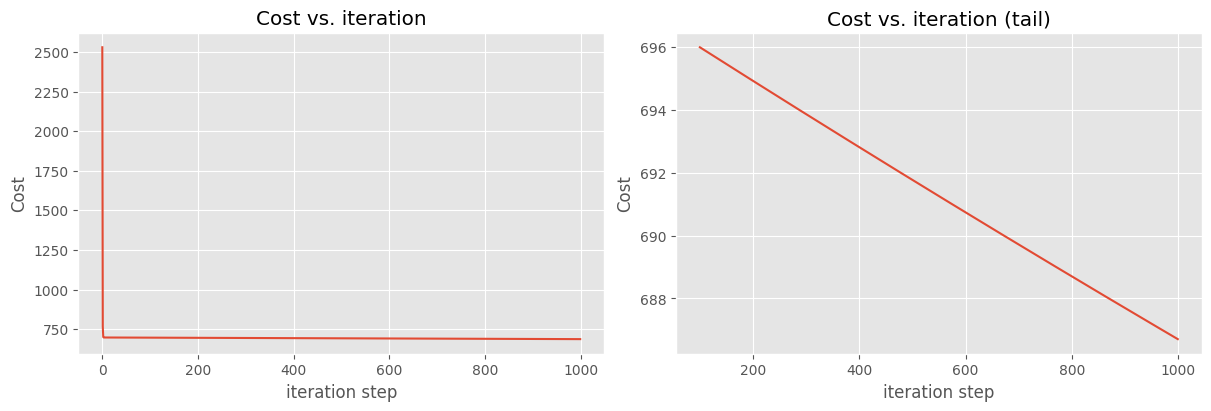

In [125]:
# plot cost versus iteration  
fig, (ax1, ax2) = plt.subplots(1, 2, constrained_layout=True, figsize=(12, 4))
ax1.plot(J_hist)
ax2.plot(100 + np.arange(len(J_hist[100:])), J_hist[100:])
ax1.set_title("Cost vs. iteration");  ax2.set_title("Cost vs. iteration (tail)")
ax1.set_ylabel('Cost')             ;  ax2.set_ylabel('Cost') 
ax1.set_xlabel('iteration step')   ;  ax2.set_xlabel('iteration step') 

plt.show()

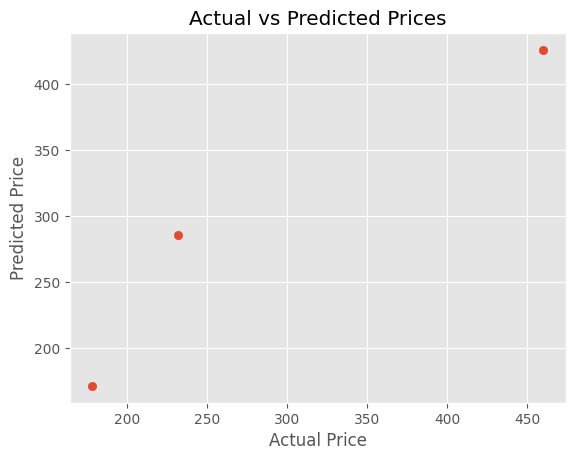

In [126]:
predictions = X_train @ w_final + b_final

plt.scatter(y_train, predictions)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.show()